# Excercise Sheet03 

## Task 1

We start from the $q$-state Potts model, where the Hamiltonian is

$$
H = -J \sum_{\langle i,j\rangle} \delta_{\sigma_i,\sigma_j},
$$

and the Boltzmann factor for a single bond is

$$
e^{\beta J \delta_{\sigma_i,\sigma_j}}.
$$

In the Fortuin--Kasteleyn representation, this can be rewritten as

$$
e^{\beta J \delta_{\sigma_i,\sigma_j}}
=
(1-p) + p\,\delta_{\sigma_i,\sigma_j},
$$

with

$$
p = 1 - e^{-\beta J}.
$$

Now consider the Ising model, which corresponds to the special case $q=2$ with spins

$$
s_i \in \{+1,-1\}.
$$

The Hamiltonian is

$$
H = -J \sum_{\langle i,j\rangle} s_i s_j.
$$

We relate the Kronecker delta to the Ising spins:

$$
\delta_{s_i,s_j} = \frac{1 + s_i s_j}{2}.
$$

Substituting into the Potts Hamiltonian:

$$
H = -J \sum_{\langle i,j\rangle} \frac{1 + s_i s_j}{2}
= -\frac{J}{2} \sum_{\langle i,j\rangle} 1
- \frac{J}{2} \sum_{\langle i,j\rangle} s_i s_j.
$$

The first term is a constant and does not affect probabilities, so the effective interaction is

$$
H_{\text{eff}} = -\frac{J}{2} \sum_{\langle i,j\rangle} s_i s_j.
$$

Thus, compared to the standard Ising form, the coupling is effectively

$$
J_{\text{Ising}} = \frac{J_{\text{Potts}}}{2}.
$$

Substituting into the Potts bond probability,

$$
p = 1 - e^{-\beta J_{\text{Potts}}}
= 1 - e^{-2\beta J_{\text{Ising}}}.
$$

Therefore, the bond (connection) probability in the Ising model is

$$
p = 1 - e^{-2\beta J},
$$

for neighboring spins in the same state.

## Task 2 (a and b). 

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import time

import pandas as pd
from collections import deque

## Metropolis class

In [75]:
class IsingMC_Metropolis:
    def __init__(self, length, temperature=1.0, J=1.0, seed=None):
        self.L = length
        self.N = length * length
        self.J = J
        self.T = temperature
        self.rng = np.random.default_rng(seed)

        self.spins = np.ones((length, length), dtype=int)
        self.M = self.N
        self.mrt_prob = np.zeros(9, dtype=float)
        self.update_probabilities()

    def update_probabilities(self):
        """
        Precompute Metropolis acceptance probabilities.
        Indexing uses 4 + s_i*h_i, where s_i*h_i in {-4,-2,0,2,4}.
        """
        self.mrt_prob.fill(0.0)

        if self.T > 0.0:
            beta = 1.0 / self.T
            for sihi in (-4, -2, 0, 2, 4):
                self.mrt_prob[sihi + 4] = min(1.0, np.exp(-2.0 * beta * self.J * sihi))
        else:
            for sihi in (-4, -2, 0):
                self.mrt_prob[sihi + 4] = 1.0

    def set_temperature(self, temperature):
        self.T = temperature
        self.update_probabilities()

    def reset_spins(self):
        """Reset to ordered all-up configuration."""
        self.spins.fill(1)
        self.M = self.N

    def randomize_spins(self):
        """Reset to random +/-1 configuration."""
        self.spins = self.rng.choice([-1, 1], size=(self.L, self.L))
        self.M = np.sum(self.spins)

    def magnetization_per_spin(self):
        return self.M / self.N

    def total_energy(self):
        """
        Total energy with periodic boundary conditions.
        Each bond counted once.
        """
        s = self.spins
        interaction = np.sum(s * np.roll(s, -1, axis=0)) + np.sum(s * np.roll(s, -1, axis=1))
        return -self.J * interaction

    def energy_per_spin(self):
        return self.total_energy() / self.N

    def mrt_step(self):
        """One single-spin Metropolis update."""
        i = self.rng.integers(self.L)
        j = self.rng.integers(self.L)

        si = self.spins[i, j]
        hi = (
            self.spins[(i + 1) % self.L, j]
            + self.spins[(i - 1) % self.L, j]
            + self.spins[i, (j + 1) % self.L]
            + self.spins[i, (j - 1) % self.L]
        )

        if self.mrt_prob[si * hi + 4] > self.rng.random():
            self.spins[i, j] *= -1
            self.M += 2 * self.spins[i, j]   # delta M = 2 * new_spin

    def mrt_sweep(self):
        """One Monte Carlo sweep = L^2 Metropolis attempts."""
        for _ in range(self.N):
            self.mrt_step()

## Wolff class

In [76]:
class IsingMC_Wolff:
    def __init__(self, length, temperature=1.0, J=1.0, seed=None):
        self.L = length
        self.N = length * length
        self.J = J
        self.T = temperature
        self.rng = np.random.default_rng(seed)

        self.spins = np.ones((length, length), dtype=int)
        self.M = self.N
        self.wolff_prob = 0.0

        # marker: 1 for sites in the current cluster, 0 otherwise
        self.wolff_marker = np.zeros((length, length), dtype=int)

        self.update_probabilities()

    def update_probabilities(self):
        """
        For Ising spins s_i = +/-1:
            p_add = 1 - exp(-2 beta J)
        """
        if self.T > 0.0:
            beta = 1.0 / self.T
            self.wolff_prob = 1.0 - np.exp(-2.0 * beta * self.J)
        else:
            self.wolff_prob = 1.0

    def set_temperature(self, temperature):
        self.T = temperature
        self.update_probabilities()

    def reset_spins(self):
        """Reset to ordered all-up configuration."""
        self.spins.fill(1)
        self.M = self.N

    def randomize_spins(self):
        """Reset to random +/-1 configuration."""
        self.spins = self.rng.choice([-1, 1], size=(self.L, self.L))
        self.M = np.sum(self.spins)

    def magnetization_per_spin(self):
        return self.M / self.N

    def total_energy(self):
        """
        Total energy with periodic boundary conditions.
        Each bond counted once.
        """
        s = self.spins
        interaction = np.sum(s * np.roll(s, -1, axis=0)) + np.sum(s * np.roll(s, -1, axis=1))
        return -self.J * interaction

    def energy_per_spin(self):
        return self.total_energy() / self.N

    def wolff_step(self):
        """
        One Wolff cluster update.
        Returns the cluster size.
        """
        self.wolff_marker.fill(0)

        # random seed site
        i0 = self.rng.integers(self.L)
        j0 = self.rng.integers(self.L)
        seed_spin = self.spins[i0, j0]

        q = deque()
        q.append((i0, j0))
        self.wolff_marker[i0, j0] = 1

        cluster_sites = [(i0, j0)]

        while q:
            i, j = q.pop()

            neighbors = [
                ((i + 1) % self.L, j),
                ((i - 1) % self.L, j),
                (i, (j + 1) % self.L),
                (i, (j - 1) % self.L),
            ]

            for ni, nj in neighbors:
                if self.wolff_marker[ni, nj] == 0 and self.spins[ni, nj] == seed_spin:
                    if self.rng.random() < self.wolff_prob:
                        self.wolff_marker[ni, nj] = 1
                        q.append((ni, nj))
                        cluster_sites.append((ni, nj))

        cluster_size = len(cluster_sites)

        # flip the whole cluster
        for i, j in cluster_sites:
            self.spins[i, j] *= -1

        # all spins in cluster had value seed_spin before the flip
        self.M -= 2 * seed_spin * cluster_size

        return cluster_size

    def wolff_sweep(self):
        """
        As stated in the skeleton:
        one sweep = L^2 Wolff steps
        """
        for _ in range(self.N):
            self.wolff_step()

## Observables 

In [77]:
def compute_observables(mags, energies, T, N):
    """
    mags     : signed magnetization per spin samples
    energies : energy per spin samples
    """
    m_abs = np.mean(np.abs(mags))
    m_mean = np.mean(mags)
    m2 = np.mean(mags**2)
    m4 = np.mean(mags**4)

    chi = (N / T) * (m2 - m_mean**2)
    binder = 1.0 - m4 / (3.0 * m2**2) if m2 > 0 else np.nan
    e_mean = np.mean(energies)

    return {
        "m_abs": m_abs,
        "m_mean": m_mean,
        "m2": m2,
        "m4": m4,
        "chi": chi,
        "binder": binder,
        "energy": e_mean,
    }

## Simulation with Metropolis

In [78]:
def simulate_metropolis(
    L,
    temperatures,
    n_therm_sweeps=500,
    n_meas=1500,
    measure_every_sweeps=5,
    J=1.0,
    seed=123,
    start_ordered=False
):
    model = IsingMC_Metropolis(L, temperature=temperatures[0], J=J, seed=seed)

    results = {
        "T": [],
        "m_abs": [],
        "chi": [],
        "binder": [],
        "energy": []
    }

    for T in temperatures:
        model.set_temperature(T)

        if start_ordered:
            model.reset_spins()
        else:
            model.randomize_spins()

        # thermalization
        for _ in range(n_therm_sweeps):
            model.mrt_sweep()

        mags = np.empty(n_meas, dtype=float)
        energies = np.empty(n_meas, dtype=float)

        for k in range(n_meas):
            for _ in range(measure_every_sweeps):
                model.mrt_sweep()

            mags[k] = model.magnetization_per_spin()
            energies[k] = model.energy_per_spin()

        obs = compute_observables(mags, energies, T, model.N)

        results["T"].append(T)
        results["m_abs"].append(obs["m_abs"])
        results["chi"].append(obs["chi"])
        results["binder"].append(obs["binder"])
        results["energy"].append(obs["energy"])

    for key in results:
        results[key] = np.array(results[key])

    return results

## Simulation with Wolff

In [79]:
def simulate_wolff(
    L,
    temperatures,
    n_therm_steps=1500,
    n_meas=1500,
    measure_every_steps=1,
    J=1.0,
    seed=456,
    start_ordered=False
):
    model = IsingMC_Wolff(L, temperature=temperatures[0], J=J, seed=seed)

    results = {
        "T": [],
        "m_abs": [],
        "chi": [],
        "binder": [],
        "energy": [],
        "avg_cluster_size": []
    }

    for T in temperatures:
        model.set_temperature(T)

        if start_ordered:
            model.reset_spins()
        else:
            model.randomize_spins()

        # thermalization
        for _ in range(n_therm_steps):
            model.wolff_step()

        mags = np.empty(n_meas, dtype=float)
        energies = np.empty(n_meas, dtype=float)
        cluster_sizes = np.empty(n_meas, dtype=float)

        for k in range(n_meas):
            total_cluster = 0
            for _ in range(measure_every_steps):
                total_cluster += model.wolff_step()

            mags[k] = model.magnetization_per_spin()
            energies[k] = model.energy_per_spin()
            cluster_sizes[k] = total_cluster / measure_every_steps

        obs = compute_observables(mags, energies, T, model.N)

        results["T"].append(T)
        results["m_abs"].append(obs["m_abs"])
        results["chi"].append(obs["chi"])
        results["binder"].append(obs["binder"])
        results["energy"].append(obs["energy"])
        results["avg_cluster_size"].append(np.mean(cluster_sizes))

    for key in results:
        results[key] = np.array(results[key])

    return results

## Plotting for Task 2(b)

In [80]:
def plot_comparison(metro_res, wolff_res, L, Tc=2.26918531421):
    T = metro_res["T"]

    plt.figure(figsize=(7, 5))
    plt.plot(T, metro_res["m_abs"], "o-", label="Metropolis")
    plt.plot(T, wolff_res["m_abs"], "s-", label="Wolff")
    plt.axvline(Tc, ls="--", c="k", alpha=0.7, label=r"$T_c$")
    plt.xlabel("T")
    plt.ylabel(r"$\langle |m| \rangle$")
    plt.title(f"Magnetisation, L={L}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(T, metro_res["chi"], "o-", label="Metropolis")
    plt.plot(T, wolff_res["chi"], "s-", label="Wolff")
    plt.axvline(Tc, ls="--", c="k", alpha=0.7, label=r"$T_c$")
    plt.xlabel("T")
    plt.ylabel(r"$\chi$")
    plt.title(f"Magnetic susceptibility, L={L}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(T, metro_res["binder"], "o-", label="Metropolis")
    plt.plot(T, wolff_res["binder"], "s-", label="Wolff")
    plt.axvline(Tc, ls="--", c="k", alpha=0.7, label=r"$T_c$")
    plt.xlabel("T")
    plt.ylabel(r"$U_L$")
    plt.title(f"Binder cumulant, L={L}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Parameters

In [81]:
Tc = 2.26918531421

L = 32
temperatures = np.linspace(2.0, 2.6, 16)

#parameters
# Metropolis
n_therm_sweeps_metro = 500
n_meas_metro = 1500
measure_every_sweeps_metro = 5

# Wolff
n_therm_steps_wolff = 1500
n_meas_wolff = 1500
measure_every_steps_wolff = 1

## Simu Run

In [82]:
start = time.perf_counter()
metro_results = simulate_metropolis(
    L=L,
    temperatures=temperatures,
    n_therm_sweeps=n_therm_sweeps_metro,
    n_meas=n_meas_metro,
    measure_every_sweeps=measure_every_sweeps_metro,
    J=1.0,
    seed=123,
    start_ordered=False
)
metro_time = time.perf_counter() - start

start = time.perf_counter()
wolff_results = simulate_wolff(
    L=L,
    temperatures=temperatures,
    n_therm_steps=n_therm_steps_wolff,
    n_meas=n_meas_wolff,
    measure_every_steps=measure_every_steps_wolff,
    J=1.0,
    seed=456,
    start_ordered=False
)
wolff_time = time.perf_counter() - start

print(f"Metropolis total runtime: {metro_time:.2f} s")
print(f"Wolff total runtime:      {wolff_time:.2f} s")

Metropolis total runtime: 369.09 s
Wolff total runtime:      32.75 s


## Plots

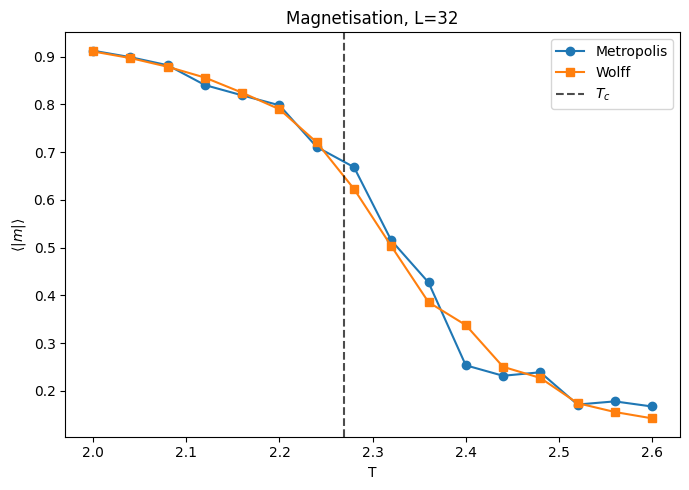

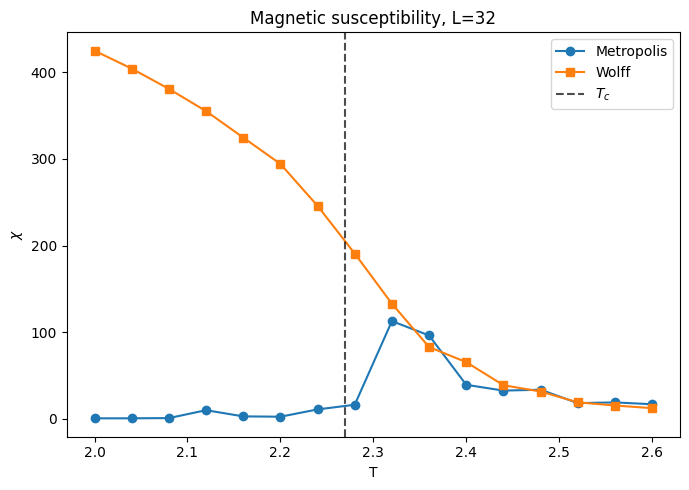

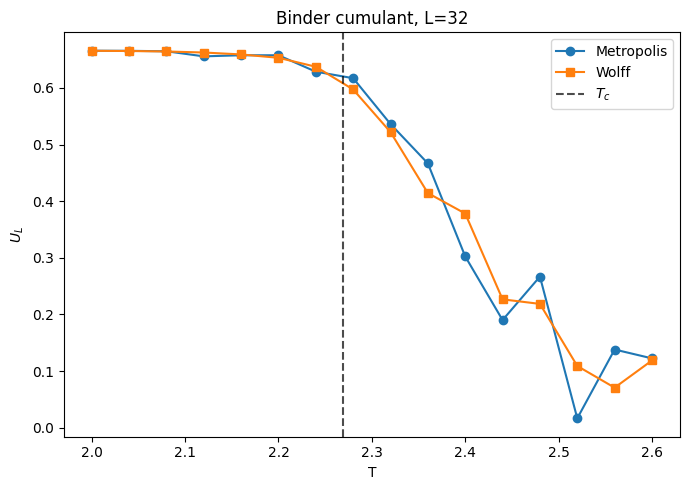

In [83]:
plot_comparison(metro_results, wolff_results, L=L, Tc=Tc)

## Average cluster size

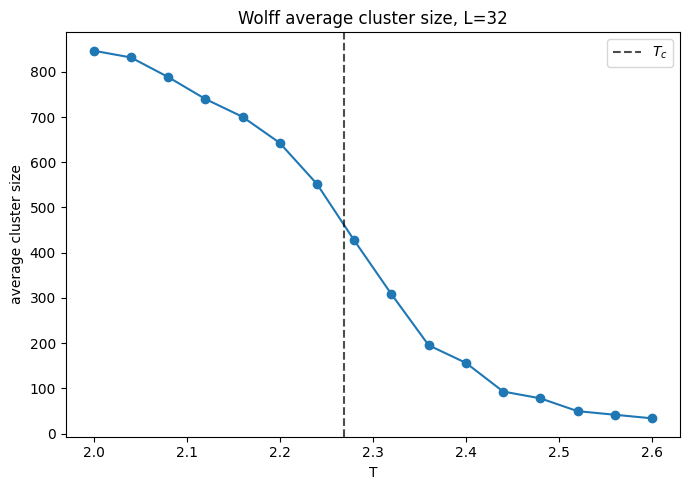

In [84]:
plt.figure(figsize=(7, 5))
plt.plot(wolff_results["T"], wolff_results["avg_cluster_size"], "o-")
plt.axvline(Tc, ls="--", c="k", alpha=0.7, label=r"$T_c$")
plt.xlabel("T")
plt.ylabel("average cluster size")
plt.title(f"Wolff average cluster size, L={L}")
plt.legend()
plt.tight_layout()
plt.show()

Metropolis total runtime (Task 2 fixed): 372.95 s
Wolff total runtime (Task 2 fixed):      32.29 s


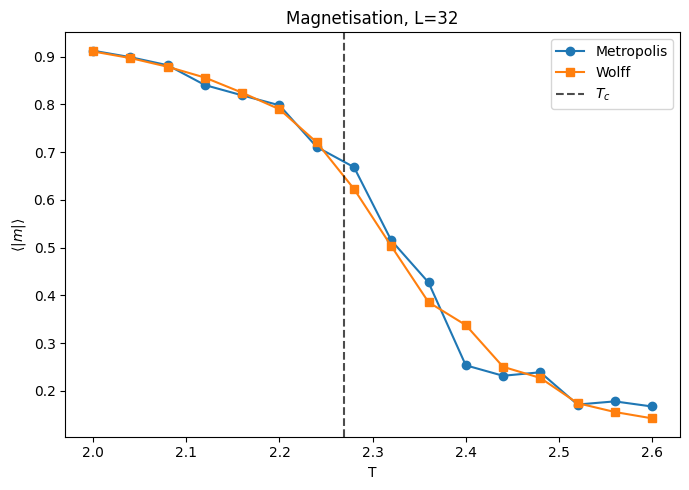

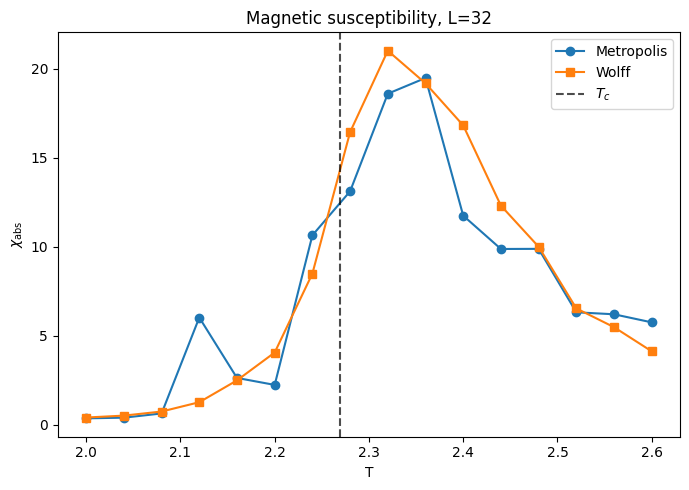

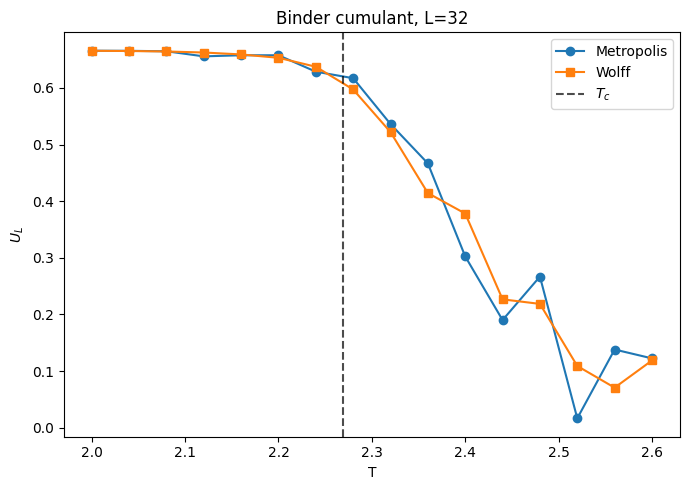

In [85]:
# I recompute susceptibility with <|m|> 


def compute_observables_task2_fixed(mags, energies, T, N):
    m_abs = np.mean(np.abs(mags))
    m_mean = np.mean(mags)
    m2 = np.mean(mags**2)
    m4 = np.mean(mags**4)

    chi_abs = (N / T) * (m2 - m_abs**2)

    binder = 1.0 - m4 / (3.0 * m2**2) if m2 > 0 else np.nan
    e_mean = np.mean(energies)

    return {
        "m_abs": m_abs,
        "m_mean": m_mean,
        "m2": m2,
        "m4": m4,
        "chi": chi_abs,
        "binder": binder,
        "energy": e_mean,
    }


def simulate_metropolis_task2_fixed(
    L,
    temperatures,
    n_therm_sweeps=500,
    n_meas=1500,
    measure_every_sweeps=5,
    J=1.0,
    seed=123,
    start_ordered=False
):
    model = IsingMC_Metropolis(L, temperature=temperatures[0], J=J, seed=seed)

    results = {
        "T": [],
        "m_abs": [],
        "chi": [],
        "binder": [],
        "energy": []
    }

    for T in temperatures:
        model.set_temperature(T)

        if start_ordered:
            model.reset_spins()
        else:
            model.randomize_spins()

        for _ in range(n_therm_sweeps):
            model.mrt_sweep()

        mags = np.empty(n_meas, dtype=float)
        energies = np.empty(n_meas, dtype=float)

        for k in range(n_meas):
            for _ in range(measure_every_sweeps):
                model.mrt_sweep()

            mags[k] = model.magnetization_per_spin()
            energies[k] = model.energy_per_spin()

        obs = compute_observables_task2_fixed(mags, energies, T, model.N)

        results["T"].append(T)
        results["m_abs"].append(obs["m_abs"])
        results["chi"].append(obs["chi"])
        results["binder"].append(obs["binder"])
        results["energy"].append(obs["energy"])

    for key in results:
        results[key] = np.array(results[key])

    return results


def simulate_wolff_task2_fixed(
    L,
    temperatures,
    n_therm_steps=1500,
    n_meas=1500,
    measure_every_steps=1,
    J=1.0,
    seed=456,
    start_ordered=False
):
    model = IsingMC_Wolff(L, temperature=temperatures[0], J=J, seed=seed)

    results = {
        "T": [],
        "m_abs": [],
        "chi": [],
        "binder": [],
        "energy": [],
        "avg_cluster_size": []
    }

    for T in temperatures:
        model.set_temperature(T)

        if start_ordered:
            model.reset_spins()
        else:
            model.randomize_spins()

        for _ in range(n_therm_steps):
            model.wolff_step()

        mags = np.empty(n_meas, dtype=float)
        energies = np.empty(n_meas, dtype=float)
        cluster_sizes = np.empty(n_meas, dtype=float)

        for k in range(n_meas):
            total_cluster = 0
            for _ in range(measure_every_steps):
                total_cluster += model.wolff_step()

            mags[k] = model.magnetization_per_spin()
            energies[k] = model.energy_per_spin()
            cluster_sizes[k] = total_cluster / measure_every_steps

        obs = compute_observables_task2_fixed(mags, energies, T, model.N)

        results["T"].append(T)
        results["m_abs"].append(obs["m_abs"])
        results["chi"].append(obs["chi"])
        results["binder"].append(obs["binder"])
        results["energy"].append(obs["energy"])
        results["avg_cluster_size"].append(np.mean(cluster_sizes))

    for key in results:
        results[key] = np.array(results[key])

    return results


def plot_comparison_task2_fixed(metro_res, wolff_res, L, Tc=2.26918531421):
    T = metro_res["T"]

    plt.figure(figsize=(7, 5))
    plt.plot(T, metro_res["m_abs"], "o-", label="Metropolis")
    plt.plot(T, wolff_res["m_abs"], "s-", label="Wolff")
    plt.axvline(Tc, ls="--", c="k", alpha=0.7, label=r"$T_c$")
    plt.xlabel("T")
    plt.ylabel(r"$\langle |m| \rangle$")
    plt.title(f"Magnetisation, L={L}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(T, metro_res["chi"], "o-", label="Metropolis")
    plt.plot(T, wolff_res["chi"], "s-", label="Wolff")
    plt.axvline(Tc, ls="--", c="k", alpha=0.7, label=r"$T_c$")
    plt.xlabel("T")
    plt.ylabel(r"$\chi_{\mathrm{abs}}$")
    plt.title(f"Magnetic susceptibility, L={L}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(T, metro_res["binder"], "o-", label="Metropolis")
    plt.plot(T, wolff_res["binder"], "s-", label="Wolff")
    plt.axvline(Tc, ls="--", c="k", alpha=0.7, label=r"$T_c$")
    plt.xlabel("T")
    plt.ylabel(r"$U_L$")
    plt.title(f"Binder cumulant, L={L}")
    plt.legend()
    plt.tight_layout()
    plt.show()


start = time.perf_counter()
metro_results_task2_fixed = simulate_metropolis_task2_fixed(
    L=L,
    temperatures=temperatures,
    n_therm_sweeps=500,
    n_meas=1500,
    measure_every_sweeps=5,
    J=1.0,
    seed=123,
    start_ordered=False
)
metro_time_task2_fixed = time.perf_counter() - start

start = time.perf_counter()
wolff_results_task2_fixed = simulate_wolff_task2_fixed(
    L=L,
    temperatures=temperatures,
    n_therm_steps=1500,
    n_meas=1500,
    measure_every_steps=1,
    J=1.0,
    seed=456,
    start_ordered=False
)
wolff_time_task2_fixed = time.perf_counter() - start

print(f"Metropolis total runtime (Task 2 fixed): {metro_time_task2_fixed:.2f} s")
print(f"Wolff total runtime (Task 2 fixed):      {wolff_time_task2_fixed:.2f} s")

plot_comparison_task2_fixed(metro_results_task2_fixed, wolff_results_task2_fixed, L=L, Tc=Tc)


# Task 3

In [86]:
class IsingMC_Metropolis(IsingBase):
    def __init__(self, length, temperature=1.0, J=1.0, seed=None):
        super().__init__(length, temperature, J, seed)
        self.mrt_prob = np.zeros(9, dtype=float)
        self.update_probabilities()

    def update_probabilities(self):
        self.mrt_prob.fill(0.0)

        if self.T > 0.0:
            beta = 1.0 / self.T
            for sihi in (-4, -2, 0, 2, 4):
                self.mrt_prob[sihi + 4] = min(1.0, np.exp(-2.0 * beta * self.J * sihi))
        else:
            for sihi in (-4, -2, 0):
                self.mrt_prob[sihi + 4] = 1.0

    def set_temperature(self, temperature):
        super().set_temperature(temperature)
        self.update_probabilities()

    def mrt_step(self):
        i = self.rng.integers(self.L)
        j = self.rng.integers(self.L)

        si = self.spins[i, j]
        hi = (
            self.spins[(i + 1) % self.L, j]
            + self.spins[(i - 1) % self.L, j]
            + self.spins[i, (j + 1) % self.L]
            + self.spins[i, (j - 1) % self.L]
        )

        if self.mrt_prob[si * hi + 4] > self.rng.random():
            self.spins[i, j] *= -1
            self.M += 2 * self.spins[i, j]

    def mrt_sweep(self):
        for _ in range(self.N):
            self.mrt_step()

NameError: name 'IsingBase' is not defined

## binning method for Task 3

We compare the performance of the Metropolis and Wolff algorithms by measuring the runtime and the linear autocorrelation time $\tau$ using the binning method.

For a stable estimate of $\tau$ in both algorithms, we use the energy per spin as the observable in the binning analysis.

In [87]:
def is_power_of_two(n):
    return n > 0 and (n & (n - 1)) == 0

def binning_deltas(data, max_level=None):
    x = np.asarray(data, dtype=float)
    n = len(x)

    if not is_power_of_two(n):
        raise ValueError("The number of samples must be a power of two.")

    levels = []
    deltas = []

    y = x.copy()
    level = 0

    while len(y) >= 32:
        if max_level is not None and level > max_level:
            break

        m = len(y)
        y_mean = np.mean(y)
        delta = np.sqrt(np.sum((y - y_mean) ** 2) / (m * (m - 1)))

        levels.append(level)
        deltas.append(delta)

        if m == 32:
            break

        y = 0.5 * (y[0::2] + y[1::2])
        level += 1

    return np.array(levels), np.array(deltas)

def tau_from_binning(data, max_level=None):
    levels, deltas = binning_deltas(data, max_level=max_level)
    delta0 = deltas[0]
    deltaA = np.max(deltas)
    tau = 0.5 * ((deltaA / delta0) ** 2 - 1.0)
    tau = max(tau, 0.0)
    plateau_level = int(levels[np.argmax(deltas)])
    return tau, levels, deltas, plateau_level

## sampling helpers using energy per spin

In [88]:
def collect_series_metropolis_energy(L, T, n_therm_sweeps, n_samples_pow=12, seed=0, start_ordered=False):
    n_samples = 2 ** n_samples_pow
    model = IsingMC_Metropolis(L, temperature=T, seed=seed)

    if start_ordered:
        model.reset_spins()
    else:
        model.randomize_spins()

    # thermalization
    for _ in range(n_therm_sweeps):
        model.mrt_sweep()

    # measurement after thermalization
    series = np.empty(n_samples, dtype=float)

    t0 = time.perf_counter()
    for k in range(n_samples):
        model.mrt_sweep()
        series[k] = model.energy_per_spin()
    runtime = time.perf_counter() - t0

    return series, runtime, n_samples


def collect_series_wolff_energy(L, T, n_therm_steps, n_samples_pow=12, seed=0, start_ordered=False):
    n_samples = 2 ** n_samples_pow
    model = IsingMC_Wolff(L, temperature=T, seed=seed)

    if start_ordered:
        model.reset_spins()
    else:
        model.randomize_spins()

    # thermalization
    for _ in range(n_therm_steps):
        model.wolff_step()

    # measurement after thermalization
    series = np.empty(n_samples, dtype=float)
    avg_cluster = 0.0

    t0 = time.perf_counter()
    for k in range(n_samples):
        csize = model.wolff_step()
        series[k] = model.energy_per_spin()
        avg_cluster += csize
    runtime = time.perf_counter() - t0

    avg_cluster /= n_samples
    return series, runtime, n_samples, avg_cluster

## benchmark wrappers 

In [89]:
def benchmark_metropolis_case(L, T, n_therm_sweeps=500, n_samples_pow=12, seed=0):
    series, runtime, n_steps = collect_series_metropolis_energy(
        L=L,
        T=T,
        n_therm_sweeps=n_therm_sweeps,
        n_samples_pow=n_samples_pow,
        seed=seed,
        start_ordered=False
    )

    tau, levels, deltas, plateau_level = tau_from_binning(series)
    step_rate = n_steps / runtime
    mc_speed = step_rate / tau if tau > 0 else np.nan

    summary = {
        "algorithm": "Metropolis",
        "L": L,
        "T": T,
        "thermalization_steps": n_therm_sweeps,
        "step_unit": "sweep",
        "measured_steps": n_steps,
        "runtime_s": runtime,
        "steps_per_s": step_rate,
        "tau_bin": tau,
        "MC_speed": mc_speed,
        "plateau_level": plateau_level,
    }

    diagnostics = {
        "series": series,
        "levels": levels,
        "deltas": deltas,
    }

    return summary, diagnostics


def benchmark_wolff_case(L, T, n_therm_steps=1000, n_samples_pow=12, seed=0):
    series, runtime, n_steps, avg_cluster = collect_series_wolff_energy(
        L=L,
        T=T,
        n_therm_steps=n_therm_steps,
        n_samples_pow=n_samples_pow,
        seed=seed,
        start_ordered=False
    )

    tau, levels, deltas, plateau_level = tau_from_binning(series)
    step_rate = n_steps / runtime
    mc_speed = step_rate / tau if tau > 0 else np.nan

    summary = {
        "algorithm": "Wolff",
        "L": L,
        "T": T,
        "thermalization_steps": n_therm_steps,
        "step_unit": "cluster_step",
        "measured_steps": n_steps,
        "runtime_s": runtime,
        "steps_per_s": step_rate,
        "tau_bin": tau,
        "MC_speed": mc_speed,
        "plateau_level": plateau_level,
        "avg_cluster_size": avg_cluster,
    }

    diagnostics = {
        "series": series,
        "levels": levels,
        "deltas": deltas,
    }

    return summary, diagnostics

## Parameters 3(a)

In [90]:
Tc = 2.26918531421

L_fixed = 16
temps_task3a = [Tc - 1.0, Tc, Tc + 1.0]

n_samples_pow_task3a = 15  
n_therm_metro_task3a = 500
n_therm_wolff_task3a = 1000

In [91]:
rows_3a = []
diag_3a = {}

for T in temps_task3a:
    summary, diagnostics = benchmark_metropolis_case(
        L=L_fixed,
        T=T,
        n_therm_sweeps=n_therm_metro_task3a,
        n_samples_pow=n_samples_pow_task3a,
        seed=100
    )
    rows_3a.append(summary)
    diag_3a[("Metropolis", L_fixed, T)] = diagnostics

for T in temps_task3a:
    summary, diagnostics = benchmark_wolff_case(
        L=L_fixed,
        T=T,
        n_therm_steps=n_therm_wolff_task3a,
        n_samples_pow=n_samples_pow_task3a,
        seed=200
    )
    rows_3a.append(summary)
    diag_3a[("Wolff", L_fixed, T)] = diagnostics

table_3a = pd.DataFrame(rows_3a)
table_3a = table_3a.sort_values(["T", "algorithm"]).reset_index(drop=True)

table_3a

,algorithm,L,T,thermalization_steps,step_unit,measured_steps,runtime_s,steps_per_s,tau_bin,MC_speed,plateau_level,avg_cluster_size
0,Metropolis,16,1.269185,500,sweep,32768,23.282353,1407.417881,0.974580,1444.127125,10,NaN
1,Wolff,16,1.269185,1000,cluster_step,32768,12.778087,2564.390116,0.084486,30352.950346,9,253.885498
2,Metropolis,16,2.269185,500,sweep,32768,23.883228,1372.008857,15.454520,88.777188,9,NaN
3,Wolff,16,2.269185,1000,cluster_step,32768,8.052357,4069.367721,2.961322,1374.172753,10,139.205994
4,Metropolis,16,3.269185,500,sweep,32768,25.009559,1310.219035,1.225436,1069.185988,10,NaN
5,Wolff,16,3.269185,1000,cluster_step,32768,0.950044,34491.016673,24.267130,1421.305943,10,7.787628


## Parameters 3(b) 

In [92]:
Ls_task3b = [8, 16, 24, 32]

n_samples_pow_task3b = 14   
n_therm_metro_task3b = 500
n_therm_wolff_task3b = 1000

## Task 3(b)

In [93]:
rows_3b = []
diag_3b = {}

for L in Ls_task3b:
    summary, diagnostics = benchmark_metropolis_case(
        L=L,
        T=Tc,
        n_therm_sweeps=n_therm_metro_task3b,
        n_samples_pow=n_samples_pow_task3b,
        seed=300 + L
    )
    rows_3b.append(summary)
    diag_3b[("Metropolis", L, Tc)] = diagnostics

for L in Ls_task3b:
    summary, diagnostics = benchmark_wolff_case(
        L=L,
        T=Tc,
        n_therm_steps=n_therm_wolff_task3b,
        n_samples_pow=n_samples_pow_task3b,
        seed=400 + L
    )
    rows_3b.append(summary)
    diag_3b[("Wolff", L, Tc)] = diagnostics

table_3b = pd.DataFrame(rows_3b)
table_3b = table_3b.sort_values(["L", "algorithm"]).reset_index(drop=True)

table_3b

,algorithm,L,T,thermalization_steps,step_unit,measured_steps,runtime_s,steps_per_s,tau_bin,MC_speed,plateau_level,avg_cluster_size
0,Metropolis,8,2.269185,500,sweep,16384,3.793951,4318.453053,7.928802,544.653889,9,NaN
1,Wolff,8,2.269185,1000,cluster_step,16384,1.451080,11290.900586,1.460789,7729.318931,9,41.353333
2,Metropolis,16,2.269185,500,sweep,16384,11.652123,1406.095708,20.079470,70.026534,9,NaN
3,Wolff,16,2.269185,1000,cluster_step,16384,4.141092,3956.443936,1.945431,2033.711159,5,139.966248
4,Metropolis,24,2.269185,500,sweep,16384,27.156371,603.320680,17.423295,34.627243,8,NaN
5,Wolff,24,2.269185,1000,cluster_step,16384,8.054803,2034.065760,3.430598,592.918695,8,283.791931
6,Metropolis,32,2.269185,500,sweep,16384,47.807773,342.705775,36.950106,9.274825,9,NaN
7,Wolff,32,2.269185,1000,cluster_step,16384,13.196815,1241.511650,4.097350,303.003561,9,470.434509


In [94]:
def plot_binning_curve(diag, title=""):
    plt.figure(figsize=(6, 4))
    plt.plot(diag["levels"], diag["deltas"], "o-")
    plt.xlabel("binning level $l$")
    plt.ylabel(r"$\Delta_A^{(l)}$")
    plt.title(title)
    plt.tight_layout()
    plt.show()

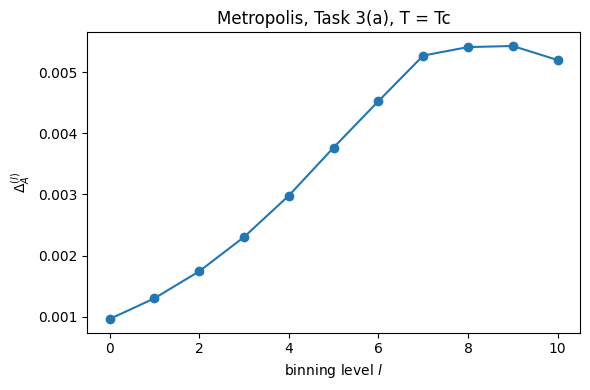

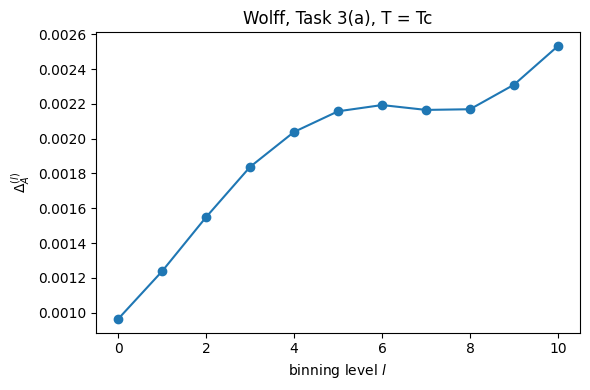

In [95]:
plot_binning_curve(diag_3a[("Metropolis", L_fixed, Tc)], title="Metropolis, Task 3(a), T = Tc")
plot_binning_curve(diag_3a[("Wolff", L_fixed, Tc)], title="Wolff, Task 3(a), T = Tc")

# Task 4: timing reference from Exercise 01

In this section, we include a timing reference based on the Exercise 01 Metropolis implementation.  
The runtime is measured only after thermalization, using the same lattice sizes, temperatures, and number of measured sweeps as in Task 3.

In [96]:
# Exercise 01 reference code based on the official solution 

def ex01_nn_sum(x, i, j, L):
    result = x[(i + 1) % L, j] + x[(i - 1) % L, j]
    result += x[i, (j + 1) % L] + x[i, (j - 1) % L]
    return int(result)


def ex01_total_energy(x, L, J=1.0):
    energy = 0.0
    for i in range(L):
        for j in range(L):
            energy += -J * x[i, j] * ex01_nn_sum(x, i, j, L) / 2.0
    return energy


def ex01_move(x, M, E, L, beta, J=1.0):
    
    #This is used only as a timing reference for Task 4.
    
    i = int(L * np.random.rand())
    j = int(L * np.random.rand())
    x_old = x[i, j]

    h_nn = ex01_nn_sum(x, i, j, L)

    table_spin_up = np.exp(-2 * J * beta * np.array([-4, -2, 0, 2, 4]))
    table_spin_down = np.exp(+2 * J * beta * np.array([-4, -2, 0, 2, 4]))

    if x_old == 1:
        R = table_spin_up[int((h_nn + 4) / 2)]
    else:
        R = table_spin_down[int((h_nn + 4) / 2)]

    eta = np.random.rand()
    if R >= eta:
        x[i, j] *= -1
        M -= 2 * x_old
        E += 2 * J * x_old * h_nn

    return x, M, E


def benchmark_ex01_reference_case(L, T, n_therm_sweeps=500, n_measured_sweeps=4096, seed=0, J=1.0):
   
    np.random.seed(seed)

    beta = 1.0 / T
    N = L * L

    x = np.random.randint(2, size=(L, L)) * 2 - 1
    M = int(np.sum(x))
    E = ex01_total_energy(x, L, J=J)

    for _ in range(n_therm_sweeps):
        for _ in range(N):
            x, M, E = ex01_move(x, M, E, L, beta, J=J)

    t0 = time.perf_counter()
    for _ in range(n_measured_sweeps):
        for _ in range(N):
            x, M, E = ex01_move(x, M, E, L, beta, J=J)
    runtime = time.perf_counter() - t0

    steps_per_s = n_measured_sweeps / runtime

    return {
        "algorithm": "Ex01 reference (timing only)",
        "L": L,
        "T": T,
        "thermalization_steps": n_therm_sweeps,
        "step_unit": "sweep",
        "measured_steps": n_measured_sweeps,
        "runtime_s": runtime,
        "steps_per_s": steps_per_s,
        "tau_bin": np.nan,
        "MC_speed": np.nan,
        "plateau_level": np.nan,
    }

In [97]:
# Task 4 added to Task 3(a), fixed L, temperatures Tc-1, Tc, Tc+1

rows_3a_ref = []

for T in temps_task3a:
    row = benchmark_ex01_reference_case(
        L=L_fixed,
        T=T,
        n_therm_sweeps=n_therm_metro_task3a,
        n_measured_sweeps=2 ** n_samples_pow_task3a,
        seed=900
    )
    rows_3a_ref.append(row)

table_3a_ref = pd.DataFrame(rows_3a_ref)
table_3a_task4 = pd.concat([table_3a, table_3a_ref], ignore_index=True)
table_3a_task4 = table_3a_task4.sort_values(["T", "algorithm"]).reset_index(drop=True)

table_3a_task4

,algorithm,L,T,thermalization_steps,step_unit,measured_steps,runtime_s,steps_per_s,tau_bin,MC_speed,plateau_level,avg_cluster_size
0,Ex01 reference (timing only),16,1.269185,500,sweep,32768,31.190354,1050.581218,NaN,NaN,NaN,NaN
1,Metropolis,16,1.269185,500,sweep,32768,23.282353,1407.417881,0.974580,1444.127125,10.0,NaN
2,Wolff,16,1.269185,1000,cluster_step,32768,12.778087,2564.390116,0.084486,30352.950346,9.0,253.885498
3,Ex01 reference (timing only),16,2.269185,500,sweep,32768,33.133405,988.971693,NaN,NaN,NaN,NaN
4,Metropolis,16,2.269185,500,sweep,32768,23.883228,1372.008857,15.454520,88.777188,9.0,NaN
5,Wolff,16,2.269185,1000,cluster_step,32768,8.052357,4069.367721,2.961322,1374.172753,10.0,139.205994
6,Ex01 reference (timing only),16,3.269185,500,sweep,32768,36.734422,892.024379,NaN,NaN,NaN,NaN
7,Metropolis,16,3.269185,500,sweep,32768,25.009559,1310.219035,1.225436,1069.185988,10.0,NaN
8,Wolff,16,3.269185,1000,cluster_step,32768,0.950044,34491.016673,24.267130,1421.305943,10.0,7.787628


In [98]:
# Task 4 added to Task 3(b), fixed T = Tc, varying L

rows_3b_ref = []

for L in Ls_task3b:
    row = benchmark_ex01_reference_case(
        L=L,
        T=Tc,
        n_therm_sweeps=n_therm_metro_task3b,
        n_measured_sweeps=2 ** n_samples_pow_task3b,
        seed=1000 + L
    )
    rows_3b_ref.append(row)

table_3b_ref = pd.DataFrame(rows_3b_ref)
table_3b_task4 = pd.concat([table_3b, table_3b_ref], ignore_index=True)
table_3b_task4 = table_3b_task4.sort_values(["L", "algorithm"]).reset_index(drop=True)

table_3b_task4

,algorithm,L,T,thermalization_steps,step_unit,measured_steps,runtime_s,steps_per_s,tau_bin,MC_speed,plateau_level,avg_cluster_size
0,Ex01 reference (timing only),8,2.269185,500,sweep,16384,4.122747,3974.049279,NaN,NaN,NaN,NaN
1,Metropolis,8,2.269185,500,sweep,16384,3.793951,4318.453053,7.928802,544.653889,9.0,NaN
2,Wolff,8,2.269185,1000,cluster_step,16384,1.451080,11290.900586,1.460789,7729.318931,9.0,41.353333
3,Ex01 reference (timing only),16,2.269185,500,sweep,16384,16.538884,990.635175,NaN,NaN,NaN,NaN
4,Metropolis,16,2.269185,500,sweep,16384,11.652123,1406.095708,20.079470,70.026534,9.0,NaN
5,Wolff,16,2.269185,1000,cluster_step,16384,4.141092,3956.443936,1.945431,2033.711159,5.0,139.966248
6,Ex01 reference (timing only),24,2.269185,500,sweep,16384,37.327365,438.927311,NaN,NaN,NaN,NaN
7,Metropolis,24,2.269185,500,sweep,16384,27.156371,603.320680,17.423295,34.627243,8.0,NaN
8,Wolff,24,2.269185,1000,cluster_step,16384,8.054803,2034.065760,3.430598,592.918695,8.0,283.791931
9,Ex01 reference (timing only),32,2.269185,500,sweep,16384,66.652395,245.812623,NaN,NaN,NaN,NaN


In [99]:
print("Task 3(a) + Task 4")
display(table_3a_task4)

print("Task 3(b) + Task 4")
display(table_3b_task4)

Task 3(a) + Task 4


,algorithm,L,T,thermalization_steps,step_unit,measured_steps,runtime_s,steps_per_s,tau_bin,MC_speed,plateau_level,avg_cluster_size
0,Ex01 reference (timing only),16,1.269185,500,sweep,32768,31.190354,1050.581218,NaN,NaN,NaN,NaN
1,Metropolis,16,1.269185,500,sweep,32768,23.282353,1407.417881,0.974580,1444.127125,10.0,NaN
2,Wolff,16,1.269185,1000,cluster_step,32768,12.778087,2564.390116,0.084486,30352.950346,9.0,253.885498
3,Ex01 reference (timing only),16,2.269185,500,sweep,32768,33.133405,988.971693,NaN,NaN,NaN,NaN
4,Metropolis,16,2.269185,500,sweep,32768,23.883228,1372.008857,15.454520,88.777188,9.0,NaN
5,Wolff,16,2.269185,1000,cluster_step,32768,8.052357,4069.367721,2.961322,1374.172753,10.0,139.205994
6,Ex01 reference (timing only),16,3.269185,500,sweep,32768,36.734422,892.024379,NaN,NaN,NaN,NaN
7,Metropolis,16,3.269185,500,sweep,32768,25.009559,1310.219035,1.225436,1069.185988,10.0,NaN
8,Wolff,16,3.269185,1000,cluster_step,32768,0.950044,34491.016673,24.267130,1421.305943,10.0,7.787628


Task 3(b) + Task 4


,algorithm,L,T,thermalization_steps,step_unit,measured_steps,runtime_s,steps_per_s,tau_bin,MC_speed,plateau_level,avg_cluster_size
0,Ex01 reference (timing only),8,2.269185,500,sweep,16384,4.122747,3974.049279,NaN,NaN,NaN,NaN
1,Metropolis,8,2.269185,500,sweep,16384,3.793951,4318.453053,7.928802,544.653889,9.0,NaN
2,Wolff,8,2.269185,1000,cluster_step,16384,1.451080,11290.900586,1.460789,7729.318931,9.0,41.353333
3,Ex01 reference (timing only),16,2.269185,500,sweep,16384,16.538884,990.635175,NaN,NaN,NaN,NaN
4,Metropolis,16,2.269185,500,sweep,16384,11.652123,1406.095708,20.079470,70.026534,9.0,NaN
5,Wolff,16,2.269185,1000,cluster_step,16384,4.141092,3956.443936,1.945431,2033.711159,5.0,139.966248
6,Ex01 reference (timing only),24,2.269185,500,sweep,16384,37.327365,438.927311,NaN,NaN,NaN,NaN
7,Metropolis,24,2.269185,500,sweep,16384,27.156371,603.320680,17.423295,34.627243,8.0,NaN
8,Wolff,24,2.269185,1000,cluster_step,16384,8.054803,2034.065760,3.430598,592.918695,8.0,283.791931
9,Ex01 reference (timing only),32,2.269185,500,sweep,16384,66.652395,245.812623,NaN,NaN,NaN,NaN


### Task 4 answer

We included an Exercise 01 Metropolis reference timing in the tables as a fixed baseline on the same hardware.  
This reference is measured only after thermalization and with the same number of measured sweeps as in Task 3.

If our optimized Metropolis implementation is faster than this Exercise 01 reference, this indicates that the code improvements are effective.  
At the same time, the Wolff algorithm should still outperform Metropolis near the critical temperature because it reduces critical slowing down substantially.

# Task 5: Swendsen–Wang algorithm

In this section we repeat Tasks 2 through 4 for the Swendsen–Wang cluster algorithm.

## Swendsen–Wang class

In [100]:
class IsingMC_SwendsenWang:
    def __init__(self, length, temperature=1.0, J=1.0, seed=None):
        self.L = length
        self.N = length * length
        self.J = J
        self.T = temperature
        self.rng = np.random.default_rng(seed)

        self.spins = np.ones((length, length), dtype=int)
        self.M = self.N
        self.sw_prob = 0.0
        self.cluster_labels = -np.ones((length, length), dtype=int)

        self.update_probabilities()

    def update_probabilities(self):
        # For Ising spins s_i = ±1:
        # p_add = 1 - exp(-2 beta J)
        if self.T > 0.0:
            beta = 1.0 / self.T
            self.sw_prob = 1.0 - np.exp(-2.0 * beta * self.J)
        else:
            self.sw_prob = 1.0

    def set_temperature(self, temperature):
        self.T = temperature
        self.update_probabilities()

    def reset_spins(self):
        self.spins.fill(1)
        self.M = self.N

    def randomize_spins(self):
        self.spins = self.rng.choice([-1, 1], size=(self.L, self.L))
        self.M = int(np.sum(self.spins))

    def magnetization_per_spin(self):
        return self.M / self.N

    def total_energy(self):
        s = self.spins
        interaction = np.sum(s * np.roll(s, -1, axis=0)) + np.sum(s * np.roll(s, -1, axis=1))
        return -self.J * interaction

    def energy_per_spin(self):
        return self.total_energy() / self.N

    def sw_step(self):
        """
        One full Swendsen-Wang update:
        1. build FK bonds between equal neighboring spins
        2. identify all connected clusters
        3. flip each cluster independently with probability 1/2
        """
        L = self.L
        s = self.spins
        rng = self.rng

        # Bonds to right and down neighbors
        same_right = (s == np.roll(s, -1, axis=1))
        same_down = (s == np.roll(s, -1, axis=0))

        bond_right = same_right & (rng.random((L, L)) < self.sw_prob)
        bond_down = same_down & (rng.random((L, L)) < self.sw_prob)

        self.cluster_labels.fill(-1)
        clusters = []
        current_label = 0

        for i0 in range(L):
            for j0 in range(L):
                if self.cluster_labels[i0, j0] != -1:
                    continue

                q = deque()
                q.append((i0, j0))
                self.cluster_labels[i0, j0] = current_label
                members = [(i0, j0)]

                while q:
                    i, j = q.pop()

                    # right neighbor
                    if bond_right[i, j]:
                        ni, nj = i, (j + 1) % L
                        if self.cluster_labels[ni, nj] == -1:
                            self.cluster_labels[ni, nj] = current_label
                            q.append((ni, nj))
                            members.append((ni, nj))

                    # left neighbor
                    if bond_right[i, (j - 1) % L]:
                        ni, nj = i, (j - 1) % L
                        if self.cluster_labels[ni, nj] == -1:
                            self.cluster_labels[ni, nj] = current_label
                            q.append((ni, nj))
                            members.append((ni, nj))

                    # down neighbor
                    if bond_down[i, j]:
                        ni, nj = (i + 1) % L, j
                        if self.cluster_labels[ni, nj] == -1:
                            self.cluster_labels[ni, nj] = current_label
                            q.append((ni, nj))
                            members.append((ni, nj))

                    # up neighbor
                    if bond_down[(i - 1) % L, j]:
                        ni, nj = (i - 1) % L, j
                        if self.cluster_labels[ni, nj] == -1:
                            self.cluster_labels[ni, nj] = current_label
                            q.append((ni, nj))
                            members.append((ni, nj))

                clusters.append(members)
                current_label += 1

        # Flip each cluster independently with probability 1/2
        for members in clusters:
            if rng.random() < 0.5:
                for i, j in members:
                    s[i, j] *= -1

        self.M = int(np.sum(s))

        cluster_sizes = np.array([len(c) for c in clusters], dtype=float)
        return {
            "n_clusters": len(clusters),
            "avg_cluster_size": np.mean(cluster_sizes),
            "max_cluster_size": np.max(cluster_sizes),
        }

    def sw_sweep(self):
        return self.sw_step()

## simulation function for Swendsen–Wang

In [101]:
def simulate_swendsen_wang(
    L,
    temperatures,
    n_therm_steps=1000,
    n_meas=1500,
    measure_every_steps=1,
    J=1.0,
    seed=789,
    start_ordered=False
):
    model = IsingMC_SwendsenWang(L, temperature=temperatures[0], J=J, seed=seed)

    results = {
        "T": [],
        "m_abs": [],
        "chi": [],
        "binder": [],
        "energy": [],
        "avg_cluster_size": [],
        "max_cluster_size": []
    }

    for T in temperatures:
        model.set_temperature(T)

        if start_ordered:
            model.reset_spins()
        else:
            model.randomize_spins()

        for _ in range(n_therm_steps):
            model.sw_step()

        mags = np.empty(n_meas, dtype=float)
        energies = np.empty(n_meas, dtype=float)
        avg_sizes = np.empty(n_meas, dtype=float)
        max_sizes = np.empty(n_meas, dtype=float)

        for k in range(n_meas):
            info = None
            for _ in range(measure_every_steps):
                info = model.sw_step()

            mags[k] = model.magnetization_per_spin()
            energies[k] = model.energy_per_spin()
            avg_sizes[k] = info["avg_cluster_size"]
            max_sizes[k] = info["max_cluster_size"]

        obs = compute_observables(mags, energies, T, model.N)

        results["T"].append(T)
        results["m_abs"].append(obs["m_abs"])
        results["chi"].append(obs["chi"])
        results["binder"].append(obs["binder"])
        results["energy"].append(obs["energy"])
        results["avg_cluster_size"].append(np.mean(avg_sizes))
        results["max_cluster_size"].append(np.mean(max_sizes))

    for key in results:
        results[key] = np.array(results[key])

    return results

## generic plotting function

In [102]:
def plot_comparison_generic(res1, res2, label1, label2, L, Tc=2.26918531421):
    T = res1["T"]

    plt.figure(figsize=(7, 5))
    plt.plot(T, res1["m_abs"], "o-", label=label1)
    plt.plot(T, res2["m_abs"], "s-", label=label2)
    plt.axvline(Tc, ls="--", c="k", alpha=0.7, label=r"$T_c$")
    plt.xlabel("T")
    plt.ylabel(r"$\langle |m| \rangle$")
    plt.title(f"Magnetisation, L={L}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(T, res1["chi"], "o-", label=label1)
    plt.plot(T, res2["chi"], "s-", label=label2)
    plt.axvline(Tc, ls="--", c="k", alpha=0.7, label=r"$T_c$")
    plt.xlabel("T")
    plt.ylabel(r"$\chi$")
    plt.title(f"Magnetic susceptibility, L={L}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(T, res1["binder"], "o-", label=label1)
    plt.plot(T, res2["binder"], "s-", label=label2)
    plt.axvline(Tc, ls="--", c="k", alpha=0.7, label=r"$T_c$")
    plt.xlabel("T")
    plt.ylabel(r"$U_L$")
    plt.title(f"Binder cumulant, L={L}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Task 5 / repeat of Task 2(b): plots around Tc

Metropolis runtime (Task 5 plots):      371.33 s
Swendsen-Wang runtime (Task 5 plots):   31.39 s


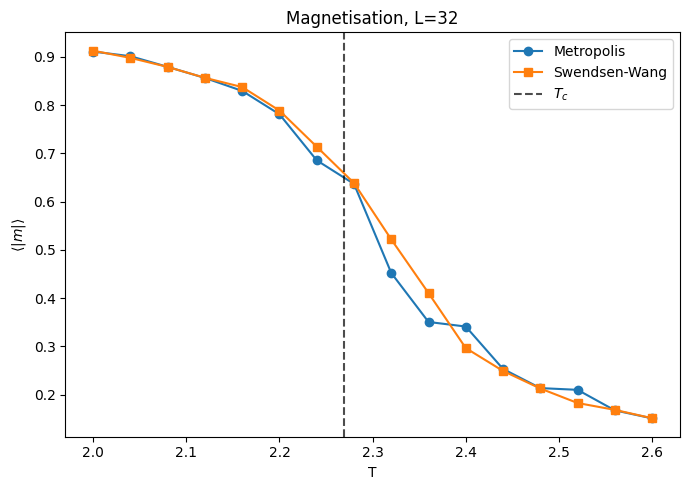

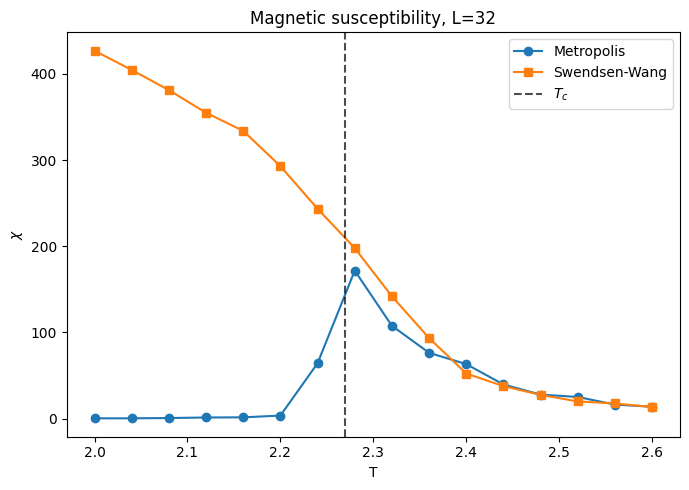

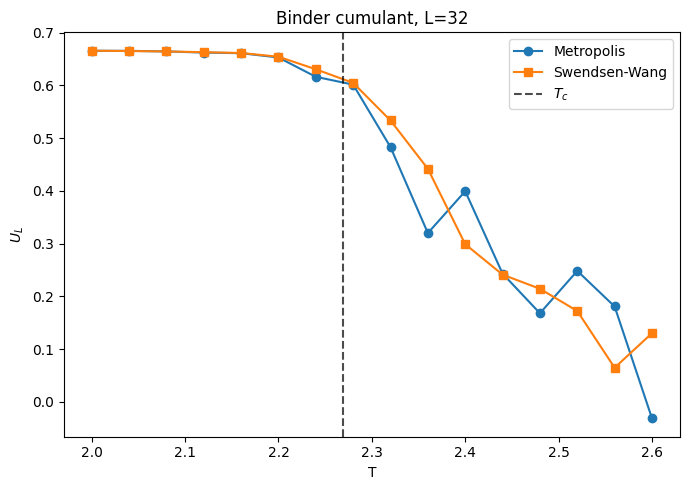

In [103]:
# We use the same temperature window as before
L_sw = 32
temperatures_sw = np.linspace(2.0, 2.6, 16)

start = time.perf_counter()
metro_results_sw = simulate_metropolis(
    L=L_sw,
    temperatures=temperatures_sw,
    n_therm_sweeps=500,
    n_meas=1500,
    measure_every_sweeps=5,
    J=1.0,
    seed=1234,
    start_ordered=False
)
metro_time_sw = time.perf_counter() - start

start = time.perf_counter()
sw_results = simulate_swendsen_wang(
    L=L_sw,
    temperatures=temperatures_sw,
    n_therm_steps=1000,
    n_meas=1500,
    measure_every_steps=1,
    J=1.0,
    seed=5678,
    start_ordered=False
)
sw_time = time.perf_counter() - start

print(f"Metropolis runtime (Task 5 plots):      {metro_time_sw:.2f} s")
print(f"Swendsen-Wang runtime (Task 5 plots):   {sw_time:.2f} s")

plot_comparison_generic(
    metro_results_sw,
    sw_results,
    label1="Metropolis",
    label2="Swendsen-Wang",
    L=L_sw,
    Tc=Tc
)

## cluster-size plot for Swendsen–Wang

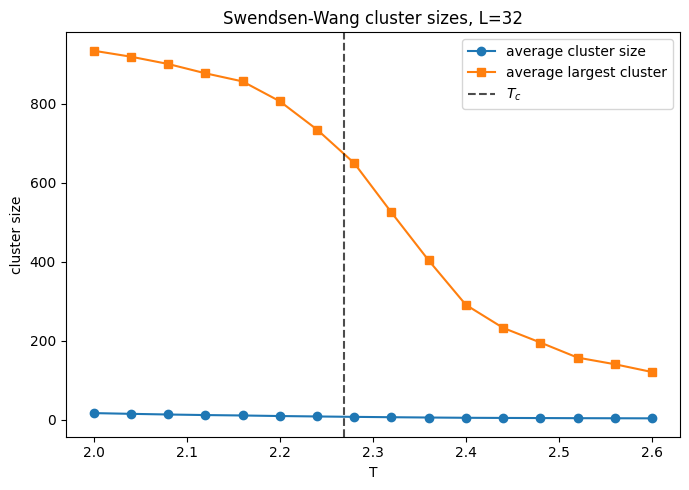

In [104]:
plt.figure(figsize=(7, 5))
plt.plot(sw_results["T"], sw_results["avg_cluster_size"], "o-", label="average cluster size")
plt.plot(sw_results["T"], sw_results["max_cluster_size"], "s-", label="average largest cluster")
plt.axvline(Tc, ls="--", c="k", alpha=0.7, label=r"$T_c$")
plt.xlabel("T")
plt.ylabel("cluster size")
plt.title(f"Swendsen-Wang cluster sizes, L={L_sw}")
plt.legend()
plt.tight_layout()
plt.show()

Metropolis total runtime (Task 5 fixed):      388.27 s
Swendsen-Wang total runtime (Task 5 fixed):   30.54 s


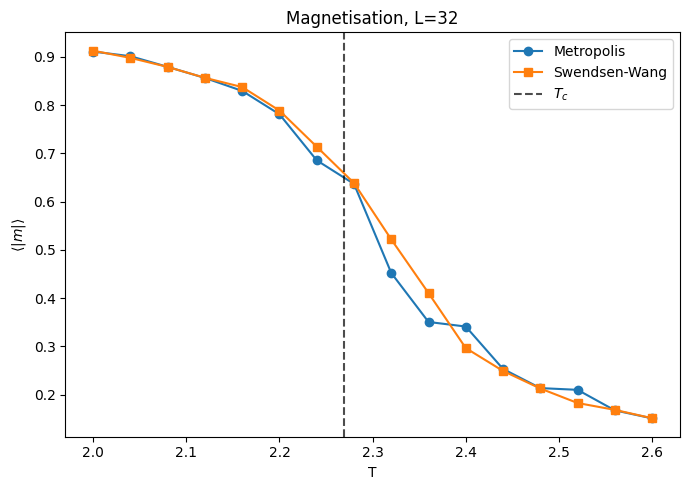

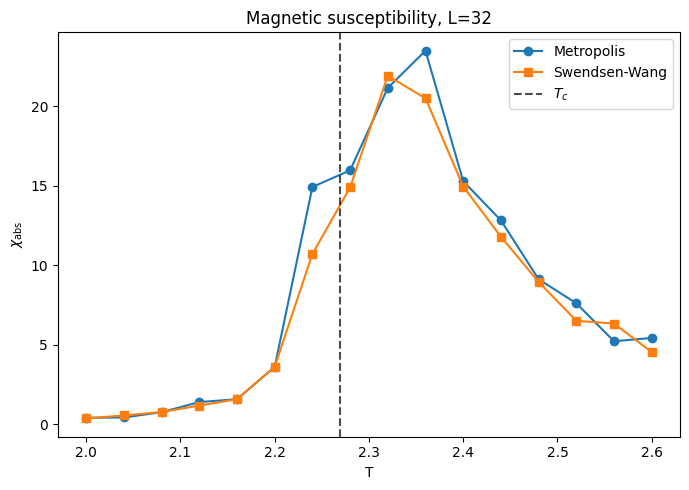

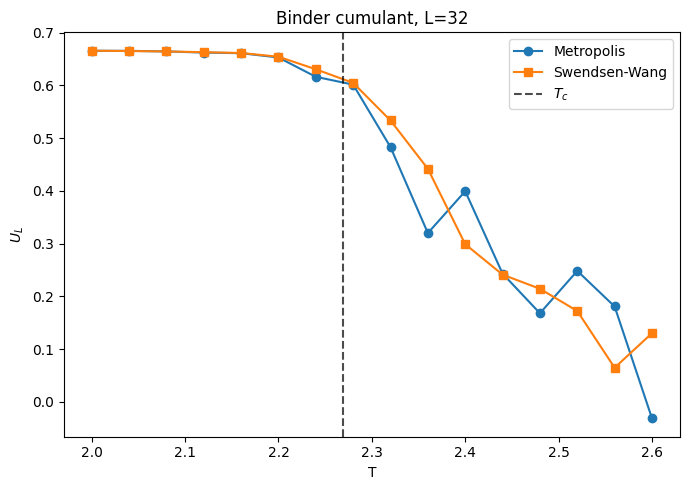

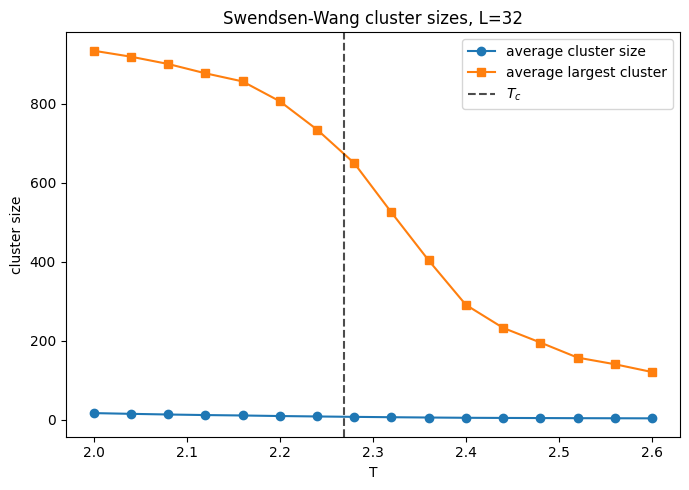

In [105]:
def compute_observables_task5_fixed(mags, energies, T, N):
    m_abs = np.mean(np.abs(mags))
    m_mean = np.mean(mags)
    m2 = np.mean(mags**2)
    m4 = np.mean(mags**4)

    chi_abs = (N / T) * (m2 - m_abs**2)

    binder = 1.0 - m4 / (3.0 * m2**2) if m2 > 0 else np.nan
    e_mean = np.mean(energies)

    return {
        "m_abs": m_abs,
        "m_mean": m_mean,
        "m2": m2,
        "m4": m4,
        "chi": chi_abs,
        "binder": binder,
        "energy": e_mean,
    }


def simulate_metropolis_task5_fixed(
    L,
    temperatures,
    n_therm_sweeps=500,
    n_meas=1500,
    measure_every_sweeps=5,
    J=1.0,
    seed=1234,
    start_ordered=False
):
    model = IsingMC_Metropolis(L, temperature=temperatures[0], J=J, seed=seed)

    results = {
        "T": [],
        "m_abs": [],
        "chi": [],
        "binder": [],
        "energy": []
    }

    for T in temperatures:
        model.set_temperature(T)

        if start_ordered:
            model.reset_spins()
        else:
            model.randomize_spins()

        for _ in range(n_therm_sweeps):
            model.mrt_sweep()

        mags = np.empty(n_meas, dtype=float)
        energies = np.empty(n_meas, dtype=float)

        for k in range(n_meas):
            for _ in range(measure_every_sweeps):
                model.mrt_sweep()

            mags[k] = model.magnetization_per_spin()
            energies[k] = model.energy_per_spin()

        obs = compute_observables_task5_fixed(mags, energies, T, model.N)

        results["T"].append(T)
        results["m_abs"].append(obs["m_abs"])
        results["chi"].append(obs["chi"])
        results["binder"].append(obs["binder"])
        results["energy"].append(obs["energy"])

    for key in results:
        results[key] = np.array(results[key])

    return results


def simulate_swendsen_wang_task5_fixed(
    L,
    temperatures,
    n_therm_steps=1000,
    n_meas=1500,
    measure_every_steps=1,
    J=1.0,
    seed=5678,
    start_ordered=False
):
    model = IsingMC_SwendsenWang(L, temperature=temperatures[0], J=J, seed=seed)

    results = {
        "T": [],
        "m_abs": [],
        "chi": [],
        "binder": [],
        "energy": [],
        "avg_cluster_size": [],
        "max_cluster_size": []
    }

    for T in temperatures:
        model.set_temperature(T)

        if start_ordered:
            model.reset_spins()
        else:
            model.randomize_spins()

        for _ in range(n_therm_steps):
            model.sw_step()

        mags = np.empty(n_meas, dtype=float)
        energies = np.empty(n_meas, dtype=float)
        avg_sizes = np.empty(n_meas, dtype=float)
        max_sizes = np.empty(n_meas, dtype=float)

        for k in range(n_meas):
            info = None
            for _ in range(measure_every_steps):
                info = model.sw_step()

            mags[k] = model.magnetization_per_spin()
            energies[k] = model.energy_per_spin()
            avg_sizes[k] = info["avg_cluster_size"]
            max_sizes[k] = info["max_cluster_size"]

        obs = compute_observables_task5_fixed(mags, energies, T, model.N)

        results["T"].append(T)
        results["m_abs"].append(obs["m_abs"])
        results["chi"].append(obs["chi"])
        results["binder"].append(obs["binder"])
        results["energy"].append(obs["energy"])
        results["avg_cluster_size"].append(np.mean(avg_sizes))
        results["max_cluster_size"].append(np.mean(max_sizes))

    for key in results:
        results[key] = np.array(results[key])

    return results


def plot_comparison_task5_fixed(metro_res, sw_res, L, Tc=2.26918531421):
    T = metro_res["T"]

    plt.figure(figsize=(7, 5))
    plt.plot(T, metro_res["m_abs"], "o-", label="Metropolis")
    plt.plot(T, sw_res["m_abs"], "s-", label="Swendsen-Wang")
    plt.axvline(Tc, ls="--", c="k", alpha=0.7, label=r"$T_c$")
    plt.xlabel("T")
    plt.ylabel(r"$\langle |m| \rangle$")
    plt.title(f"Magnetisation, L={L}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(T, metro_res["chi"], "o-", label="Metropolis")
    plt.plot(T, sw_res["chi"], "s-", label="Swendsen-Wang")
    plt.axvline(Tc, ls="--", c="k", alpha=0.7, label=r"$T_c$")
    plt.xlabel("T")
    plt.ylabel(r"$\chi_{\mathrm{abs}}$")
    plt.title(f"Magnetic susceptibility, L={L}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(T, metro_res["binder"], "o-", label="Metropolis")
    plt.plot(T, sw_res["binder"], "s-", label="Swendsen-Wang")
    plt.axvline(Tc, ls="--", c="k", alpha=0.7, label=r"$T_c$")
    plt.xlabel("T")
    plt.ylabel(r"$U_L$")
    plt.title(f"Binder cumulant, L={L}")
    plt.legend()
    plt.tight_layout()
    plt.show()


try:
    L_sw
except NameError:
    L_sw = 32

try:
    temperatures_sw
except NameError:
    temperatures_sw = np.linspace(2.0, 2.6, 16)

start = time.perf_counter()
metro_results_task5_fixed = simulate_metropolis_task5_fixed(
    L=L_sw,
    temperatures=temperatures_sw,
    n_therm_sweeps=500,
    n_meas=1500,
    measure_every_sweeps=5,
    J=1.0,
    seed=1234,
    start_ordered=False
)
metro_time_task5_fixed = time.perf_counter() - start

start = time.perf_counter()
sw_results_task5_fixed = simulate_swendsen_wang_task5_fixed(
    L=L_sw,
    temperatures=temperatures_sw,
    n_therm_steps=1000,
    n_meas=1500,
    measure_every_steps=1,
    J=1.0,
    seed=5678,
    start_ordered=False
)
sw_time_task5_fixed = time.perf_counter() - start

print(f"Metropolis total runtime (Task 5 fixed):      {metro_time_task5_fixed:.2f} s")
print(f"Swendsen-Wang total runtime (Task 5 fixed):   {sw_time_task5_fixed:.2f} s")

plot_comparison_task5_fixed(
    metro_results_task5_fixed,
    sw_results_task5_fixed,
    L=L_sw,
    Tc=Tc
)

plt.figure(figsize=(7, 5))
plt.plot(sw_results_task5_fixed["T"], sw_results_task5_fixed["avg_cluster_size"], "o-", label="average cluster size")
plt.plot(sw_results_task5_fixed["T"], sw_results_task5_fixed["max_cluster_size"], "s-", label="average largest cluster")
plt.axvline(Tc, ls="--", c="k", alpha=0.7, label=r"$T_c$")
plt.xlabel("T")
plt.ylabel("cluster size")
plt.title(f"Swendsen-Wang cluster sizes, L={L_sw}")
plt.legend()
plt.tight_layout()
plt.show()

## sampling helper for Swendsen–Wang (Task 3 repeat)

In [106]:
def collect_series_swendsen_wang(L, T, n_therm_steps, n_samples_pow=12, seed=0, start_ordered=False):
    n_samples = 2 ** n_samples_pow
    model = IsingMC_SwendsenWang(L, temperature=T, seed=seed)

    if start_ordered:
        model.reset_spins()
    else:
        model.randomize_spins()

    for _ in range(n_therm_steps):
        model.sw_step()

    series = np.empty(n_samples, dtype=float)
    avg_cluster_size = 0.0

    t0 = time.perf_counter()
    for k in range(n_samples):
        info = model.sw_step()
        series[k] = model.magnetization_per_spin()
        avg_cluster_size += info["avg_cluster_size"]
    runtime = time.perf_counter() - t0

    avg_cluster_size /= n_samples
    return series, runtime, n_samples, avg_cluster_size

## benchmark wrapper for Swendsen–Wang

In [107]:
def benchmark_swendsen_wang_case(L, T, n_therm_steps=1000, n_samples_pow=12, seed=0):
    series, runtime, n_steps, avg_cluster_size = collect_series_swendsen_wang(
        L=L,
        T=T,
        n_therm_steps=n_therm_steps,
        n_samples_pow=n_samples_pow,
        seed=seed,
        start_ordered=False
    )

    tau, levels, deltas, plateau_level = tau_from_binning(series)
    step_rate = n_steps / runtime
    mc_speed = step_rate / tau if tau > 0 else np.nan

    summary = {
        "algorithm": "Swendsen-Wang",
        "L": L,
        "T": T,
        "thermalization_steps": n_therm_steps,
        "step_unit": "SW_step",
        "measured_steps": n_steps,
        "runtime_s": runtime,
        "steps_per_s": step_rate,
        "tau_bin": tau,
        "MC_speed": mc_speed,
        "plateau_level": plateau_level,
        "avg_cluster_size": avg_cluster_size,
    }

    diagnostics = {
        "series": series,
        "levels": levels,
        "deltas": deltas,
    }

    return summary, diagnostics

## Task 5 / repeat of Task 3(a): fixed L, temperatures Tc,-1,Tc,Tc+1

In [108]:
rows_5a = []
diag_5a = {}

for T in temps_task3a:
    summary, diagnostics = benchmark_metropolis_case(
        L=L_fixed,
        T=T,
        n_therm_sweeps=n_therm_metro_task3a,
        n_samples_pow=n_samples_pow_task3a,
        seed=1100
    )
    rows_5a.append(summary)
    diag_5a[("Metropolis", L_fixed, T)] = diagnostics

for T in temps_task3a:
    summary, diagnostics = benchmark_swendsen_wang_case(
        L=L_fixed,
        T=T,
        n_therm_steps=n_therm_wolff_task3a,   
        n_samples_pow=n_samples_pow_task3a,
        seed=1200
    )
    rows_5a.append(summary)
    diag_5a[("Swendsen-Wang", L_fixed, T)] = diagnostics

table_5a = pd.DataFrame(rows_5a)
table_5a = table_5a.sort_values(["T", "algorithm"]).reset_index(drop=True)

table_5a

,algorithm,L,T,thermalization_steps,step_unit,measured_steps,runtime_s,steps_per_s,tau_bin,MC_speed,plateau_level,avg_cluster_size
0,Metropolis,16,1.269185,500,sweep,32768,23.260342,1408.749729,1.161894,1.212460e+03,10,NaN
1,Swendsen-Wang,16,1.269185,1000,SW_step,32768,7.267080,4509.101130,0.004318,1.044215e+06,2,159.077703
2,Metropolis,16,2.269185,500,sweep,32768,24.695123,1326.901659,28.996637,4.576054e+01,10,NaN
3,Swendsen-Wang,16,2.269185,1000,SW_step,32768,6.861302,4775.769950,0.137579,3.471282e+04,9,8.451876
4,Metropolis,16,3.269185,500,sweep,32768,26.033826,1258.670177,1.234112,1.019899e+03,9,NaN
5,Swendsen-Wang,16,3.269185,1000,SW_step,32768,7.086840,4623.781358,0.075944,6.088373e+04,10,2.547045


## Task 5 / repeat of Task 3(b): fixed T=Tc, Varying L.

In [109]:
rows_5b = []
diag_5b = {}

for L in Ls_task3b:
    summary, diagnostics = benchmark_metropolis_case(
        L=L,
        T=Tc,
        n_therm_sweeps=n_therm_metro_task3b,
        n_samples_pow=n_samples_pow_task3b,
        seed=1300 + L
    )
    rows_5b.append(summary)
    diag_5b[("Metropolis", L, Tc)] = diagnostics

for L in Ls_task3b:
    summary, diagnostics = benchmark_swendsen_wang_case(
        L=L,
        T=Tc,
        n_therm_steps=n_therm_wolff_task3b,
        n_samples_pow=n_samples_pow_task3b,
        seed=1400 + L
    )
    rows_5b.append(summary)
    diag_5b[("Swendsen-Wang", L, Tc)] = diagnostics

table_5b = pd.DataFrame(rows_5b)
table_5b = table_5b.sort_values(["L", "algorithm"]).reset_index(drop=True)

table_5b

,algorithm,L,T,thermalization_steps,step_unit,measured_steps,runtime_s,steps_per_s,tau_bin,MC_speed,plateau_level,avg_cluster_size
0,Metropolis,8,2.269185,500,sweep,16384,3.298340,4967.347197,5.549392,895.115610,9,NaN
1,Swendsen-Wang,8,2.269185,1000,SW_step,16384,1.043246,15704.831917,0.127204,123461.703568,8,9.713323
2,Metropolis,16,2.269185,500,sweep,16384,12.572388,1303.173256,28.374076,45.928306,9,NaN
3,Swendsen-Wang,16,2.269185,1000,SW_step,16384,3.315515,4941.615894,0.000000,NaN,0,8.520410
4,Metropolis,24,2.269185,500,sweep,16384,27.760089,590.199834,39.591416,14.907268,9,NaN
5,Swendsen-Wang,24,2.269185,1000,SW_step,16384,6.913622,2369.814283,0.025999,91149.550518,8,8.145651
6,Metropolis,32,2.269185,500,sweep,16384,48.065646,340.867156,52.122023,6.539791,9,NaN
7,Swendsen-Wang,32,2.269185,1000,SW_step,16384,12.114477,1352.431503,0.130998,10324.067289,9,8.131331


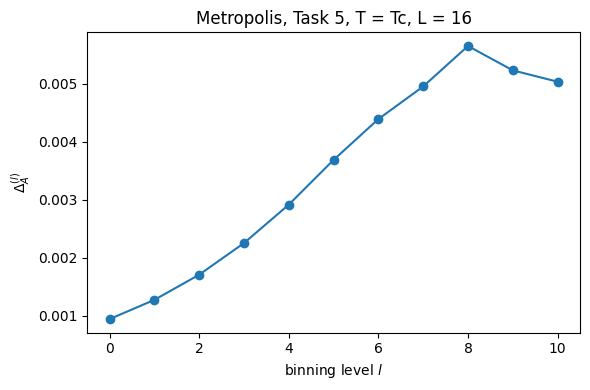

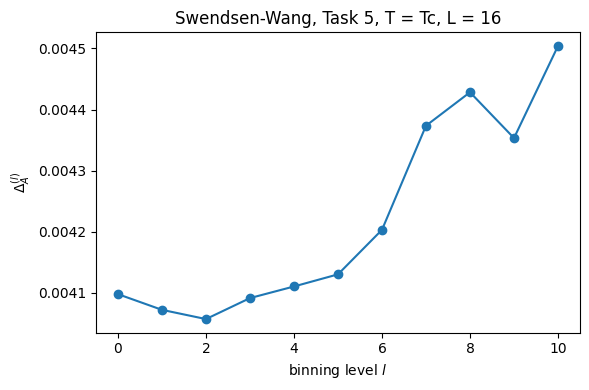

In [110]:
L_diag_sw = 16

# Metro at T=T_c
summary_metro_sw_diag, diag_metro_sw_diag = benchmark_metropolis_case(
    L=L_diag_sw,
    T=Tc,
    n_therm_sweeps=n_therm_metro_task3a,
    n_samples_pow=n_samples_pow_task3a,
    seed=1700
)

# Swendsen-Wang  at T = Tc
summary_sw_diag, diag_sw_diag = benchmark_swendsen_wang_case(
    L=L_diag_sw,
    T=Tc,
    n_therm_steps=n_therm_wolff_task3a,
    n_samples_pow=n_samples_pow_task3a,
    seed=1800
)

plot_binning_curve(
    diag_metro_sw_diag,
    title=f"Metropolis, Task 5, T = Tc, L = {L_diag_sw}"
)

plot_binning_curve(
    diag_sw_diag,
    title=f"Swendsen-Wang, Task 5, T = Tc, L = {L_diag_sw}"
)

## Task 5 / repeat of Task 4: Exercise 01 reference to table 5(a)

In [111]:
rows_5a_ref = []

for T in temps_task3a:
    row = benchmark_ex01_reference_case(
        L=L_fixed,
        T=T,
        n_therm_sweeps=n_therm_metro_task3a,
        n_measured_sweeps=2 ** n_samples_pow_task3a,
        seed=1500
    )
    rows_5a_ref.append(row)

table_5a_ref = pd.DataFrame(rows_5a_ref)
table_5a_with_ref = pd.concat([table_5a, table_5a_ref], ignore_index=True)
table_5a_with_ref = table_5a_with_ref.sort_values(["T", "algorithm"]).reset_index(drop=True)

table_5a_with_ref

,algorithm,L,T,thermalization_steps,step_unit,measured_steps,runtime_s,steps_per_s,tau_bin,MC_speed,plateau_level,avg_cluster_size
0,Ex01 reference (timing only),16,1.269185,500,sweep,32768,29.724671,1102.383930,NaN,NaN,NaN,NaN
1,Metropolis,16,1.269185,500,sweep,32768,23.260342,1408.749729,1.161894,1.212460e+03,10.0,NaN
2,Swendsen-Wang,16,1.269185,1000,SW_step,32768,7.267080,4509.101130,0.004318,1.044215e+06,2.0,159.077703
3,Ex01 reference (timing only),16,2.269185,500,sweep,32768,32.328030,1013.609563,NaN,NaN,NaN,NaN
4,Metropolis,16,2.269185,500,sweep,32768,24.695123,1326.901659,28.996637,4.576054e+01,10.0,NaN
5,Swendsen-Wang,16,2.269185,1000,SW_step,32768,6.861302,4775.769950,0.137579,3.471282e+04,9.0,8.451876
6,Ex01 reference (timing only),16,3.269185,500,sweep,32768,35.880313,913.258483,NaN,NaN,NaN,NaN
7,Metropolis,16,3.269185,500,sweep,32768,26.033826,1258.670177,1.234112,1.019899e+03,9.0,NaN
8,Swendsen-Wang,16,3.269185,1000,SW_step,32768,7.086840,4623.781358,0.075944,6.088373e+04,10.0,2.547045


## Task 5 / repeat of Task 4: Exercise 01 reference to table 5(b)

In [112]:
rows_5b_ref = []

for L in Ls_task3b:
    row = benchmark_ex01_reference_case(
        L=L,
        T=Tc,
        n_therm_sweeps=n_therm_metro_task3b,
        n_measured_sweeps=2 ** n_samples_pow_task3b,
        seed=1600 + L
    )
    rows_5b_ref.append(row)

table_5b_ref = pd.DataFrame(rows_5b_ref)
table_5b_with_ref = pd.concat([table_5b, table_5b_ref], ignore_index=True)
table_5b_with_ref = table_5b_with_ref.sort_values(["L", "algorithm"]).reset_index(drop=True)

table_5b_with_ref

,algorithm,L,T,thermalization_steps,step_unit,measured_steps,runtime_s,steps_per_s,tau_bin,MC_speed,plateau_level,avg_cluster_size
0,Ex01 reference (timing only),8,2.269185,500,sweep,16384,4.110690,3985.705448,NaN,NaN,NaN,NaN
1,Metropolis,8,2.269185,500,sweep,16384,3.298340,4967.347197,5.549392,895.115610,9.0,NaN
2,Swendsen-Wang,8,2.269185,1000,SW_step,16384,1.043246,15704.831917,0.127204,123461.703568,8.0,9.713323
3,Ex01 reference (timing only),16,2.269185,500,sweep,16384,16.263816,1007.389652,NaN,NaN,NaN,NaN
4,Metropolis,16,2.269185,500,sweep,16384,12.572388,1303.173256,28.374076,45.928306,9.0,NaN
5,Swendsen-Wang,16,2.269185,1000,SW_step,16384,3.315515,4941.615894,0.000000,NaN,0.0,8.520410
6,Ex01 reference (timing only),24,2.269185,500,sweep,16384,36.970900,443.159348,NaN,NaN,NaN,NaN
7,Metropolis,24,2.269185,500,sweep,16384,27.760089,590.199834,39.591416,14.907268,9.0,NaN
8,Swendsen-Wang,24,2.269185,1000,SW_step,16384,6.913622,2369.814283,0.025999,91149.550518,8.0,8.145651
9,Ex01 reference (timing only),32,2.269185,500,sweep,16384,66.416630,246.685205,NaN,NaN,NaN,NaN


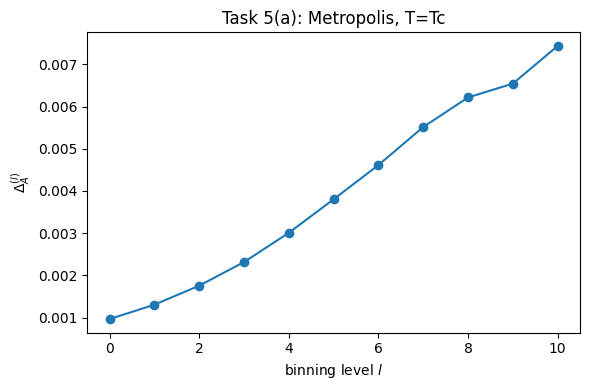

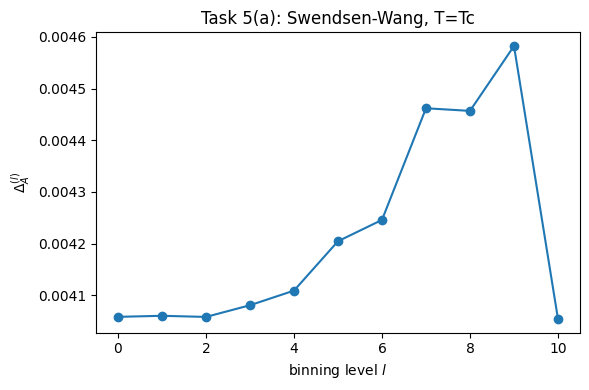

In [113]:
plot_binning_curve(diag_5a[("Metropolis", L_fixed, Tc)], title="Task 5(a): Metropolis, T=Tc")
plot_binning_curve(diag_5a[("Swendsen-Wang", L_fixed, Tc)], title="Task 5(a): Swendsen-Wang, T=Tc")

### Task 5 interpretation

The Swendsen–Wang algorithm reproduces the same thermodynamic observables as Metropolis around the critical temperature, namely the magnetisation, the magnetic susceptibility, and the Binder cumulant.  
However, its autocorrelation time is significantly smaller near \(T_c\), which leads to a larger Monte Carlo speed.

At fixed system size and varying temperature, the reduction of critical slowing down is most visible close to \(T_c\).  
At fixed \(T=T_c\) and increasing lattice size, the autocorrelation time of Metropolis grows much more strongly than that of Swendsen–Wang.  
This shows that the cluster update substantially improves the sampling efficiency in the critical regime.